In [1]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [2]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
print(df_all_sorted.head())
print(len(df_all_sorted))




astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0
   TIME_NS  TIME_S  TIME_ABS  EVENT   MCRUN  TEL_ID  \
0   238868       0    238868   1007  263210       2   
1  1029262       0   1029262   3519  263210       2   
2  1030456       0   1030456   3519  263210       9   
3  3274338       0   3274338   3803  263210       9   
4  3678725       0   3678725   3805  263210       2   

                                                  HG  \
0  [[2156, 2287, 2081, 2114, 2197, 2323, 2141, 22...   
1  [[2069, 2138, 2184, 2049, 2241, 2220, 2179, 22...   
2  [[2126, 2121, 2134, 2208, 2194, 2174, 2226, 22...   
3 

In [3]:
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
print(len(df_all_sorted))

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,
            "mcrun": mcrun,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


4224


In [4]:
def intersection(p1, d1, p2, d2):
    """
    p1, p2 = centroidi
    d1, d2 = direzioni 
    """
    A = np.array([d1, -d2]).T
    b = p2 - p1

    # determinante per capire se sono parallele
    det = np.linalg.det(A)
    if abs(det) < 1e-6:
        return None  
    # risolvi i parametri t
    t = np.linalg.solve(A, b)[0]

    # punto di intersezione
    return p1 + t * d1
inters_hg = []
dfR=pd.DataFrame(results)
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_evt = df_evt["HG"].values

    for i in range(len(rette_evt)):
        tel1 = rette_evt[i]["tel"]
        for j in range(i+1, len(rette_evt)):
            tel2 = rette_evt[j]["tel"]
            if tel1 == tel2: #controllo: no più telescopi nello stesso evento
                continue
    
            P = intersection(rette_evt[i]["p0"], rette_evt[i]["d"],
                             rette_evt[j]["p0"], rette_evt[j]["d"])
            if P is not None:
                inters_hg.append({
                    "event": event,
                    "mcrun": mcrun,
                    "P": P
                })

df_int_hg = pd.DataFrame(inters_hg)
P = np.vstack(df_int_hg["P"].values)
df_int_hg = df_int_hg[np.sqrt(P[:,0]**2 + P[:,1]**2) < 400]
            


In [15]:
from sklearn.cluster import DBSCAN

epsilon = 20
min_samples = 6

results_clusters = []

for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):

    # punti di intersezione dell'evento
    P = np.vstack(df_evt["P"].values)

    if len(P) < min_samples:
        continue

    # DBSCAN
    dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
    labels = dbscan.fit_predict(P)

    # cluster validi (senza rumore)
    cl_labels = set(labels)
    cl_labels.discard(-1)
    n_clusters = len(cl_labels)

    if n_clusters == 0:
        continue

    # mediane dei cluster
    centri = []
    for lab in cl_labels:
        centro = np.median(P[labels == lab], axis=0)
        centri.append(centro)

    # ==========================
    # distanza retta–mediana
    # ==========================
    dfR_evt = dfR[(dfR["event"] == event) & (dfR["mcrun"] == mcrun)]
    r_median = []
    r_median1=[]
    for r in dfR_evt["HG"]:
        p0 = r["p0"]
        d  = r["d"]

        norm_d = np.linalg.norm(d)
        if norm_d == 0:
            continue

        d_unit = d / norm_d

        # distanza dal cluster più vicino
        dists = []
        for c in centri:
            v = c - p0
            dist = abs(v[0] * d_unit[1] - v[1] * d_unit[0]) #distanza retta mediana
            dists.append(dist)

        if len(dists) == 0:
            continue

        r_median.append(np.min(dists))
        r_median1.append(np.max(dists))
    if len(r_median) == 0:
        continue

    r_median = np.array(r_median)#distanza retta-mediana cluster piu vicino 
    r_median1 = np.array(r_median1)#distanza retta-mediana cluster piu lontano 

    results_clusters.append({
        "event": event,
        "mcrun": mcrun,
        "n_clusters": n_clusters,
        "median_dist": r_median,
        "median_dist1": r_median1
    })


In [16]:

df_res = pd.DataFrame(results_clusters)
prob = df_res["n_clusters"].value_counts(normalize=True)


print("P(1 cluster) =", prob.get(1, 0.0)) #senza sigma_clipp= 0.806 #con =0.82
print("P(2 cluster) =", prob.get(2, 0.0))#senza sigma clip= 0.181  #con =0.16
print("P(3 cluster) =", prob.get(3, 0.0)) 
#con taglio migliora notevolmente


P(1 cluster) = 0.9736147757255936
P(2 cluster) = 0.026385224274406333
P(3 cluster) = 0.0


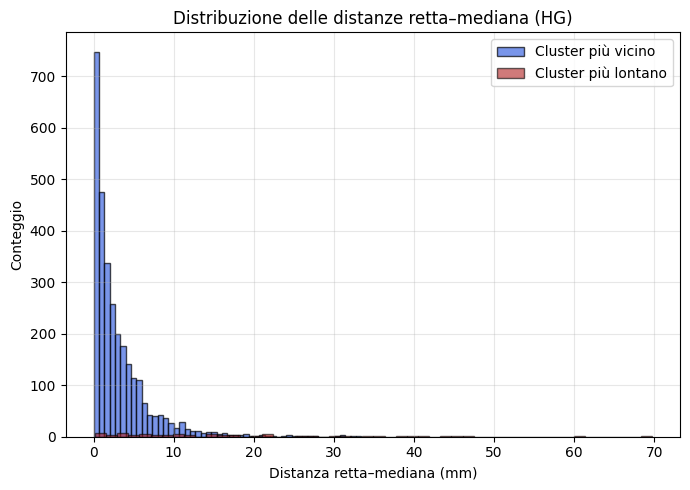

In [22]:

median_dist = np.hstack(df_res["median_dist"].to_list())

if (df_res["n_clusters"] > 1).any():
    median_dist1 = np.hstack(df_res.loc[df_res["n_clusters"] > 1, "median_dist1"].to_list())

# ============================================
# Plot
# ============================================
fig, ax = plt.subplots(figsize=(7, 5))

# --- cluster più vicino ---
ax.hist(median_dist,bins=50,alpha=0.7,color="royalblue",edgecolor="black",
        label="Cluster più vicino")

# --- cluster più lontano (se esiste) ---
if (df_res["n_clusters"] > 1).any():
    ax.hist(median_dist1,bins=50,alpha=0.6,color="firebrick",edgecolor="black",
        label="Cluster più lontano")

# ============================================
# Stile
# ============================================
ax.set_xlabel("Distanza retta–mediana (mm)")
ax.set_ylabel("Conteggio")
ax.set_title("Distribuzione delle distanze retta–mediana (HG)")
ax.legend()
#ax.set_yscale("log")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))

groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]

fake_events = []

for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):

    # metà telescopi da A
    nA = len(dfA) // 2
    partA = dfA.sample(n=nA, replace=False)

    # metà telescopi da B
    nB = len(dfB) // 2
    partB = dfB.sample(n=nB, replace=False)

    # unione → evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)

    # etichetta evento fittizio
    df_fake["FAKE_EVENT"] = i

    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns


Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'HG', 'LG',
       'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [26]:
#########ora stessa analisi di sopra
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []

for event, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "event": event,   
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": itel
            }
        })


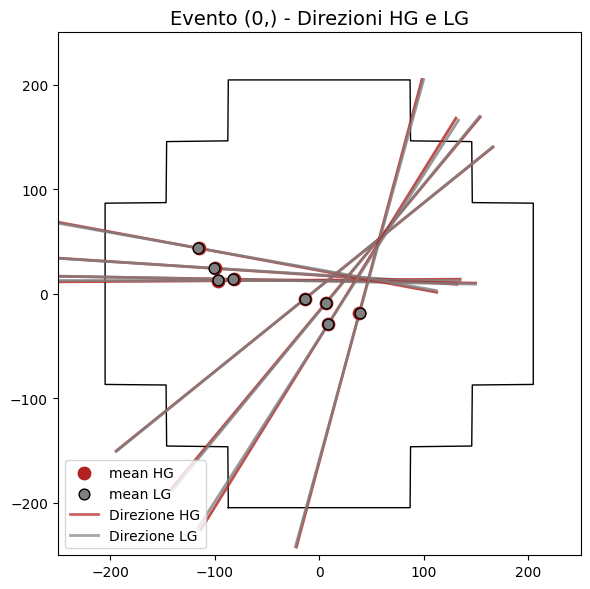

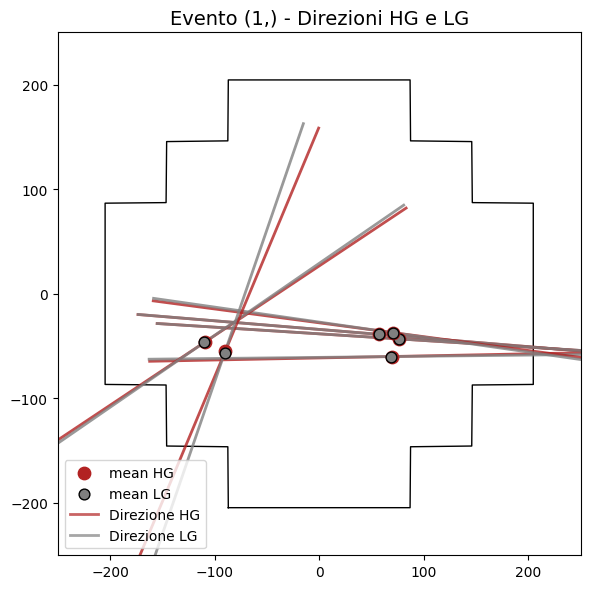

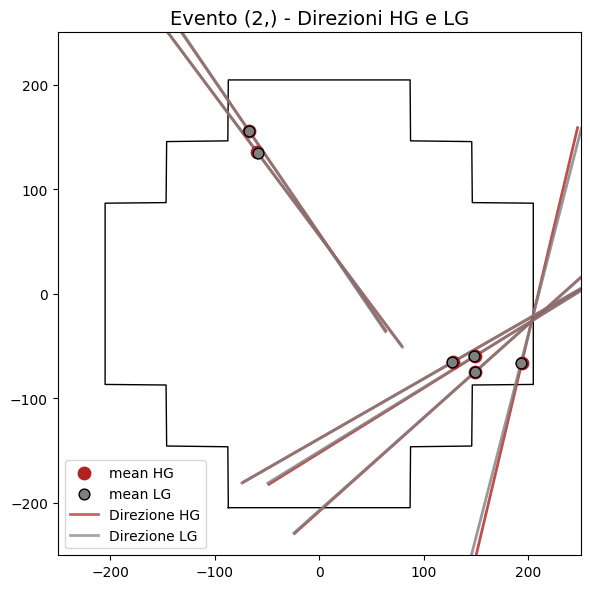

In [29]:
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.40 * diag

# Trova tutti gli eventi presenti
eventi_presenti = sorted({r["event"] for r in results})[:3]

# Loop su ogni evento
for event in eventi_presenti:
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # footprint camera
    ax.plot(xfp, yfp, 'k-', linewidth=1)

    # seleziona tutte le rette di questo evento
    rette_evento = [r for r in results if r["event"] == event]

    for r in rette_evento:
        # HG
        p0 = r["HG"]["p0"]
        d  = r["HG"]["d"]
        ax.scatter(p0[0], p0[1], s=80, color="firebrick", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="firebrick", linewidth=2, alpha=0.8)

        # LG
        p0 = r["LG"]["p0"]
        d  = r["LG"]["d"]
        ax.scatter(p0[0], p0[1], s=60, color="grey", edgecolor="black", zorder=5)
        x1, y1 = p0[0] - L*d[0], p0[1] - L*d[1]
        x2, y2 = p0[0] + L*d[0], p0[1] + L*d[1]
        ax.plot([x1, x2], [y1, y2], color="grey", linewidth=2, alpha=0.8)
    
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-250, 250)
    ax.grid(False)
    ax.set_title(f"Evento {event} - Direzioni HG e LG", fontsize=14)
    
    # dummy legends
    ax.scatter([], [], color='firebrick', s=80, label="mean HG")
    ax.scatter([], [], color='grey', s=60, edgecolor='black', label="mean LG")
    ax.plot([], [], color='firebrick', linewidth=2, alpha=0.7, label="Direzione HG")
    ax.plot([], [], color='grey', linewidth=2, alpha=0.7, label="Direzione LG")
    ax.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()